# MuJoCo Dynamics: Forward and Inverse Dynamics

## Learning Objectives

- Understand the manipulator equation $M(q)\ddot q = \tau + \tau_{passive} - h(q, \dot q)$ and where each term lives in MuJoCo
- Identify the physical parameters (inertia, gravity torque, damping) of a model from MuJoCo quantities
- Predict accelerations by hand and verify against `mj_forward`
- Use `mj_inverse` to compute the torques required for a desired motion
- Verify inverse dynamics against the analytic equation and on a chaotic double pendulum
- Combine inverse dynamics with feedback to build a **computed torque** controller that far outperforms plain PD

## The System

We use the simple pendulum bundled with `dms` (`pendulum.xml`): a massless
rod of length $L = 0.5$ m with a point mass $m = 1$ kg at the tip, driven by
a torque motor at the hinge and damped with $b = 0.05$ N m s/rad. The hinge
axis is +Y, so the pendulum swings in the vertical **X-Z plane**:

- $q = 0$: rod horizontal (pointing along +x) -- maximum gravity torque
- $q = \pm\pi/2$: rod hanging straight down -- equilibrium

## Setup

In [1]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
import dms

model_path = dms.get_asset_path("mujoco_models/pendulum.xml")
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

print(f"nq={model.nq}, nv={model.nv}, nu={model.nu} (torque motor)")
print(f"timestep = {model.opt.timestep} s")
print(f"damping  = {model.dof_damping[0]} N m s/rad")

nq=1, nv=1, nu=1 (torque motor)
timestep = 0.001 s
damping  = 0.05 N m s/rad


## Section 1: The Equation of Motion

Every MuJoCo system obeys the standard manipulator equation:

$$M(q)\,\ddot q = \underbrace{\tau_{\text{act}}}_{\text{motors}} + \underbrace{\tau_{\text{passive}}}_{\text{springs, dampers}} + \underbrace{\tau_{\text{applied}}}_{\text{external}} - \underbrace{h(q, \dot q)}_{\text{gravity + Coriolis}}$$

| Term | Meaning | MuJoCo |
|---|---|---|
| $M(q)$ | mass matrix (configuration-dependent inertia) | `mj_fullM` |
| $h(q, \dot q)$ | bias forces: gravity + Coriolis/centrifugal | `data.qfrc_bias` |
| $\tau_{\text{passive}}$ | damping/spring forces | `data.qfrc_passive` |
| $\tau_{\text{act}}$ | actuator forces | `data.qfrc_actuator` |
| $\tau_{\text{applied}}$ | external wrenches | `data.xfrc_applied` |

**Forward dynamics** answers: *given the torques, what is the acceleration?*
This is what `mj_step` solves every timestep.

**Inverse dynamics** answers the reverse question: *given a desired motion
$(q, \dot q, \ddot q)$, what torque is required?*

For our pendulum everything collapses to one scalar ODE:

$$I\,\ddot q = \tau - m g L \cos q - b\,\dot q$$

Note the gravity torque is $-mgl\cos q$ (maximal when the rod is
*horizontal*, zero when hanging) -- unlike the classic point-mass pendulum
where it is $-mgl\sin q$, because here $q$ is measured from horizontal.

Every parameter of this equation can be identified directly from the model:

In [2]:
M = np.zeros((model.nv, model.nv))

# Inertia I = M[0,0]: a point mass at L plus the sphere's own inertia (2/5 m r^2)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)
mujoco.mj_fullM(model, data, M)
I = M[0, 0]
m, L, g, r = 1.0, 0.5, 9.81, 0.05
print(f"I (MuJoCo)   = {I:.6f}")
print(f"I (analytic) = {m * L**2 + 0.4 * m * r**2:.6f}  = m L^2 + 2/5 m r^2")

# Gravity torque qfrc_bias[0] = -mgl*cos(q)  ->  identify mgl at a known q
q = 0.3
mujoco.mj_resetData(model, data)
data.qpos[0] = q
mujoco.mj_forward(model, data)
mgl = -data.qfrc_bias[0] / np.cos(q)
print(f"\nmgl (MuJoCo)   = {mgl:.6f}")
print(f"mgl (analytic) = {(m * L + 0.001 * 0.25) * g:.6f}  (tip mass + tiny rod contribution)")

# Passive force: pure damping, qfrc_passive = -b * qdot
mujoco.mj_resetData(model, data)
data.qvel[0] = 0.7
mujoco.mj_forward(model, data)
b = model.dof_damping[0]
print(f"\nqfrc_passive   = {data.qfrc_passive[0]:+.6f}  at qdot = 0.7")
print(f"-b * qdot      = {-b * 0.7:+.6f}  with b = {b}")

I (MuJoCo)   = 0.251086
I (analytic) = 0.251000  = m L^2 + 2/5 m r^2

mgl (MuJoCo)   = 4.907452
mgl (analytic) = 4.907452  (tip mass + tiny rod contribution)

qfrc_passive   = -0.035000  at qdot = 0.7
-b * qdot      = -0.035000  with b = 0.05


## Section 2: Forward Dynamics

`mj_forward` evaluates the right-hand side of the equation of motion and
solves for `data.qacc`. We can reproduce it by hand.

Note the relationship to `mj_step`: **`mj_step` = `mj_forward` + integrate**.
Each call internally runs the full forward pipeline (computing `data.qacc`
at the current state) and then advances `qpos`/`qvel` by one timestep -- which
is why the simulation loop below never calls `mj_forward` explicitly. Call
`mj_forward` standalone only when you need derived quantities (`qacc`,
`qfrc_bias`, ...) *without* advancing time.

$$\ddot q = \frac{\tau + \tau_{\text{passive}} - h(q, \dot q)}{M(q)}$$

In [3]:
# One step of forward dynamics, by hand vs MuJoCo
mujoco.mj_resetData(model, data)
data.qpos[0] = 0.3     # position
data.qvel[0] = 0.7     # velocity
data.ctrl[0] = 0.05    # motor torque
mujoco.mj_forward(model, data)

qacc_hand = (data.ctrl[0] + data.qfrc_passive[0] - data.qfrc_bias[0]) / I
print(f"qacc (MuJoCo) = {data.qacc[0]:.9f}")
print(f"qacc (by hand)= {qacc_hand:.9f}")

qacc (MuJoCo) = 18.731722948
qacc (by hand)= 18.731722948


max |MuJoCo - RK4| over 5.0 s = 1.36e-03 rad


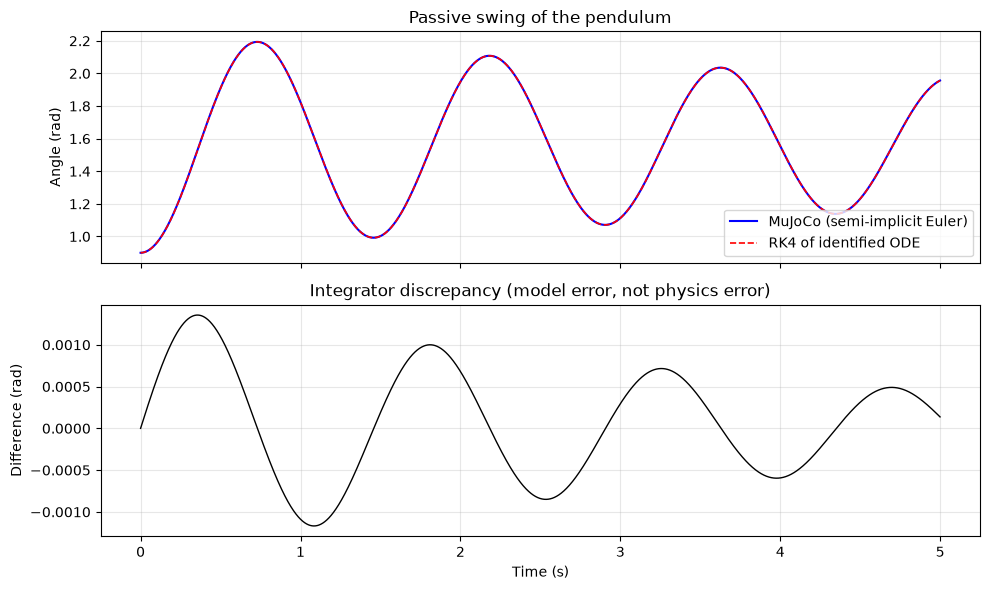

In [4]:
# Free swing (tau = 0): compare MuJoCo's integrator against exact RK4
# of the identified ODE. MuJoCo uses semi-implicit Euler by default.
def f(y):
    """State derivative for the passive pendulum: y = [q, qdot]."""
    q, qd = y
    return np.array([qd, (mgl * np.cos(q) - b * qd) / I])

dt = model.opt.timestep
duration = 5.0

y = np.array([0.9, 0.0])            # RK4 state
mujoco.mj_resetData(model, data)
data.qpos[0] = 0.9
mujoco.mj_forward(model, data)

times, q_mj, q_rk = [], [], []
while data.time < duration:
    times.append(data.time)
    q_mj.append(data.qpos[0])
    q_rk.append(y[0])
    k1 = f(y)
    k2 = f(y + dt / 2 * k1)
    k3 = f(y + dt / 2 * k2)
    k4 = f(y + dt * k3)
    y = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    mujoco.mj_step(model, data)

times = np.array(times)
q_mj = np.array(q_mj)
q_rk = np.array(q_rk)
print(f"max |MuJoCo - RK4| over {duration} s = {np.abs(q_mj - q_rk).max():.2e} rad")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(times, q_mj, 'b-', linewidth=1.5, label='MuJoCo (semi-implicit Euler)')
axes[0].plot(times, q_rk, 'r--', linewidth=1.2, label='RK4 of identified ODE')
axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('Passive swing of the pendulum')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(times, q_mj - q_rk, 'k-', linewidth=1)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Difference (rad)')
axes[1].set_title('Integrator discrepancy (model error, not physics error)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Section 3: Inverse Dynamics

Given a state $(q, \dot q)$ and a **desired acceleration** $\ddot q^*$,
inverse dynamics returns the required generalized force:

$$\tau = M(q)\,\ddot q^* + h(q, \dot q) - \tau_{\text{passive}}$$

In MuJoCo: fill `data.qpos`, `data.qvel` **and `data.qacc`** with the desired
values, then call **`mujoco.mj_inverse(model, data)`**. The required force
appears in `data.qfrc_inverse`.

For the pendulum the analytic answer is

$$\tau = I\,\ddot q - mgl\cos q + b\,\dot q$$

(e.g. to *hold* the rod horizontal, the motor must supply exactly minus the
gravity torque, $\tau = -mgl$).

Let's track a smooth trajectory $q^*(t) = 0.5 + 0.4\sin(\pi t)$ and compare
`mj_inverse` against the analytic formula:

In [5]:
def traj(t):
    """Desired trajectory (position, velocity, acceleration)."""
    return (0.5 + 0.4 * np.sin(np.pi * t),
            0.4 * np.pi * np.cos(np.pi * t),
            -0.4 * np.pi**2 * np.sin(np.pi * t))

print(f"{'t (s)':>6} | {'tau (mj_inverse)':>16} | {'tau (analytic)':>14}")
errs = []
for t in np.linspace(0.0, 2.0, 100):
    qd, vd, ad = traj(t)
    mujoco.mj_resetData(model, data)
    data.qpos[0] = qd
    data.qvel[0] = vd
    data.qacc[0] = ad
    mujoco.mj_inverse(model, data)
    tau_analytic = I * ad - mgl * np.cos(qd) + b * vd
    errs.append(abs(data.qfrc_inverse[0] - tau_analytic))
    if abs(t - round(t)) < 1e-9 and t % 0.5 == 0:
        print(f"{t:6.2f} | {data.qfrc_inverse[0]:16.6f} | {tau_analytic:14.6f}")
print(f"\nmax |mj_inverse - analytic| over 100 samples = {max(errs):.2e} N m")

 t (s) | tau (mj_inverse) | tau (analytic)
  0.00 |        -4.243863 |      -4.243863
  2.00 |        -4.243863 |      -4.243863

max |mj_inverse - analytic| over 100 samples = 1.78e-15 N m


### A Harder Case: the Double Pendulum

The value of `mj_inverse` is that it works for *any* model -- no derivations
needed. For the double pendulum, $M(q)$ is a full $2\times2$ matrix that
depends on both angles, and $h$ mixes gravity with strong Coriolis coupling
(its motion is chaotic). We never write the equations down; MuJoCo handles
everything:

In [6]:
dp_model = mujoco.MjModel.from_xml_path(dms.get_asset_path("mujoco_models/double_pendulum.xml"))
dp_data = mujoco.MjData(dp_model)

mujoco.mj_resetData(dp_model, dp_data)
dp_data.qpos[:] = [np.pi / 2, np.pi / 4]
mujoco.mj_forward(dp_model, dp_data)

M_dp = np.zeros((dp_model.nv, dp_model.nv))
mujoco.mj_fullM(dp_model, dp_data, M_dp)
print("Mass matrix M(q) (depends on both angles):")
print(np.round(M_dp, 5))
print(f"\nBias forces h(q, qdot) = {np.round(dp_data.qfrc_bias, 4)}")

Mass matrix M(q) (depends on both angles):
[[0.60377 0.17688]
 [0.17688 0.0885 ]]

Bias forces h(q, qdot) = [9.0917 1.7342]


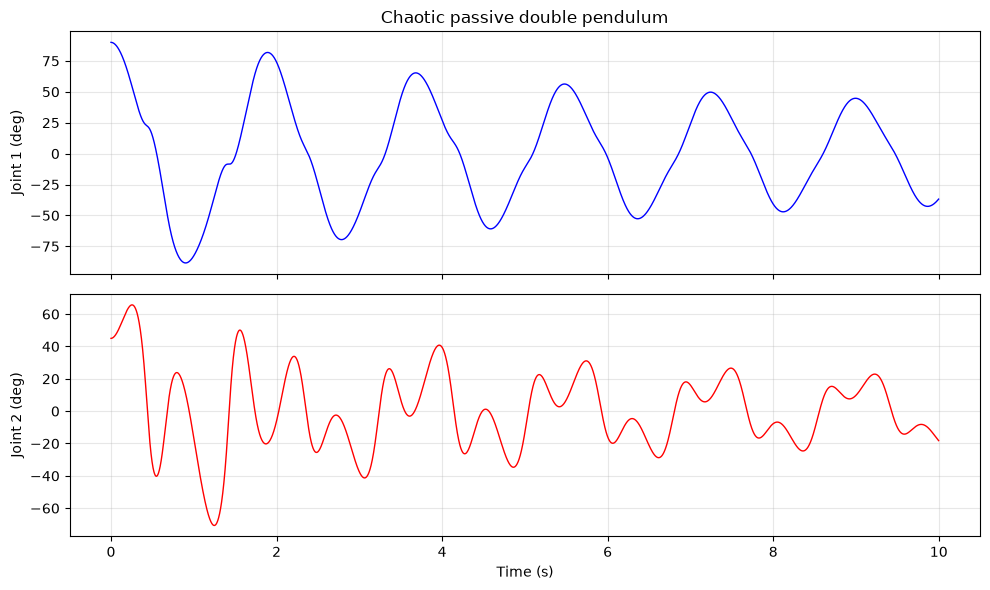

mj_inverse on recorded passive motion: max |tau| = 1.78e-15 N m
(zero, as expected -- no motors acted)


In [7]:
# Consistency check: simulate passively (no motors), record (q, qdot, qacc),
# then ask mj_inverse what force that motion requires. Answer: zero.
mujoco.mj_resetData(dp_model, dp_data)
dp_data.qpos[:] = [np.pi / 2, np.pi / 4]
mujoco.mj_forward(dp_model, dp_data)

rec_t, rec_q, rec_v, rec_a = [], [], [], []
while dp_data.time < 10.0:
    mujoco.mj_forward(dp_model, dp_data)
    rec_t.append(dp_data.time)
    rec_q.append(dp_data.qpos.copy())
    rec_v.append(dp_data.qvel.copy())
    rec_a.append(dp_data.qacc.copy())
    mujoco.mj_step(dp_model, dp_data)
rec_q = np.array(rec_q); rec_v = np.array(rec_v); rec_a = np.array(rec_a)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(rec_t, np.degrees(rec_q[:, 0]), 'b-', linewidth=1, label='joint 1')
axes[1].plot(rec_t, np.degrees(rec_q[:, 1]), 'r-', linewidth=1, label='joint 2')
axes[0].set_ylabel('Joint 1 (deg)'); axes[1].set_ylabel('Joint 2 (deg)')
axes[1].set_xlabel('Time (s)')
axes[0].set_title('Chaotic passive double pendulum')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

errs = []
for i in range(0, len(rec_t), 25):
    mujoco.mj_resetData(dp_model, dp_data)
    dp_data.qpos[:] = rec_q[i]
    dp_data.qvel[:] = rec_v[i]
    dp_data.qacc[:] = rec_a[i]
    mujoco.mj_inverse(dp_model, dp_data)
    errs.append(np.abs(dp_data.qfrc_inverse).max())
print(f"mj_inverse on recorded passive motion: max |tau| = {max(errs):.2e} N m")
print("(zero, as expected -- no motors acted)")

## Section 4: Model-Based Control -- Computed Torque

Inverse dynamics turns into a controller. To track a reference
$(q^*, \dot q^*, \ddot q^*)$:

**Plain PD** (no model): $\tau = K_p e + K_d \dot e$ with
$e = q^* - q$. The motor must fight gravity and the inertial demands of the
trajectory *through the feedback loop alone* -- resulting in lag and large
torques.

**Computed torque** (feedback linearization): command an acceleration

$$\ddot q_{cmd} = \ddot q^* + K_p e + K_d \dot e$$

then compute the torque that *exactly produces* it with `mj_inverse`:
$\tau = M\ddot q_{cmd} + h - \tau_{passive}$. The model terms cancel the
nonlinearities, and the PD only handles small residual errors.

In [8]:
Kp, Kd = 60.0, 12.0

def run(control, record_video=False):
    """Simulate 5 s of tracking; control is 'pd' or 'ct' (computed torque)."""
    frames = []
    if record_video:
        renderer = mujoco.Renderer(model, height=480, width=640)
        cam = dms.mujoco.make_camera(model)
    mujoco.mj_resetData(model, data)
    t_arr, e_arr, u_arr = [], [], []
    while data.time < 5.0:
        mujoco.mj_forward(model, data)
        q_des, vd_des, ad_des = traj(data.time)
        e = q_des - data.qpos[0]
        ed = vd_des - data.qvel[0]
        if control == 'pd':
            data.ctrl[0] = Kp * e + Kd * ed
        else:  # computed torque
            data.qacc[0] = ad_des + Kp * e + Kd * ed
            mujoco.mj_inverse(model, data)
            data.ctrl[0] = data.qfrc_inverse[0]
        t_arr.append(data.time)
        e_arr.append(e)
        u_arr.append(data.ctrl[0])
        if record_video and len(frames) < data.time * 30:
            renderer.update_scene(data, camera=cam)
            frames.append(renderer.render().copy())
        mujoco.mj_step(model, data)
    if record_video:
        renderer.close()
    return np.array(t_arr), np.array(e_arr), np.array(u_arr), frames

results = {}
for kind in ('pd', 'ct'):
    t_arr, e_arr, u_arr, frames = run(kind, record_video=(kind == 'ct'))
    results[kind] = (t_arr, e_arr, u_arr)
    ss = t_arr > 4.0   # after the transient
    print(f"{kind:>3}: RMS error (t>4s) = {np.sqrt((e_arr[ss]**2).mean()):.2e} rad, "
          f"max error = {np.abs(e_arr[ss]).max():.2e} rad, "
          f"peak torque = {np.abs(u_arr).max():5.1f} N m")
print(f"\nPredicted PD lag ~ gravity torque / Kp = {mgl / Kp:.3f} rad")

 pd: RMS error (t>4s) = 6.55e-02 rad, max error = 6.75e-02 rad, peak torque =  45.1 N m


 ct: RMS error (t>4s) = 2.58e-04 rad, max error = 3.65e-04 rad, peak torque =   6.4 N m

Predicted PD lag ~ gravity torque / Kp = 0.082 rad


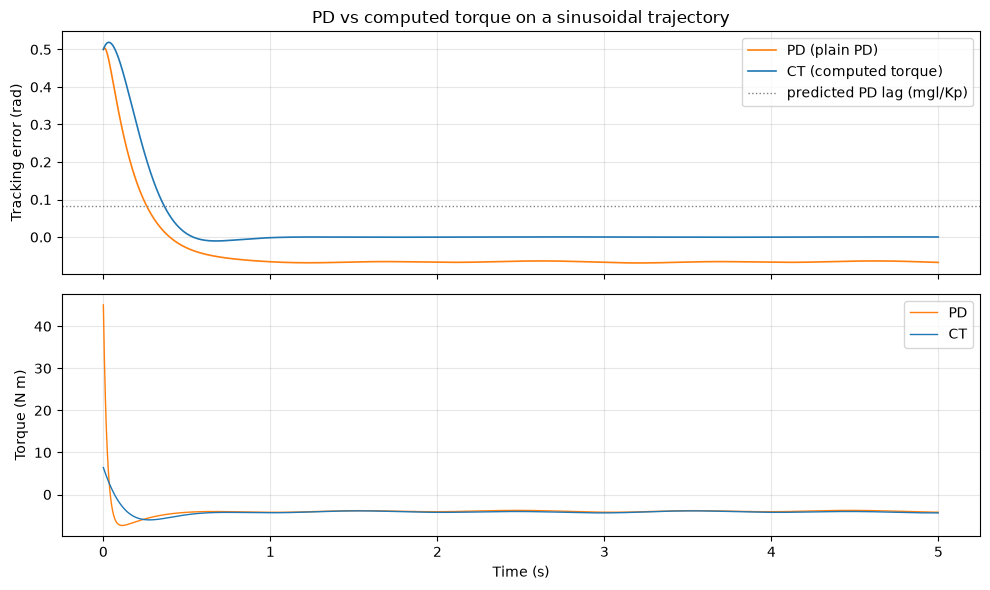

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for kind, c in (('pd', 'C1'), ('ct', 'C0')):
    t_arr, e_arr, u_arr = results[kind]
    axes[0].plot(t_arr, e_arr, color=c, linewidth=1.2,
                 label=f"{kind.upper()} ({'plain PD' if kind == 'pd' else 'computed torque'})")
    axes[1].plot(t_arr, u_arr, color=c, linewidth=1, label=kind.upper())
axes[0].set_ylabel('Tracking error (rad)')
axes[0].set_title('PD vs computed torque on a sinusoidal trajectory')
axes[0].axhline(mgl / Kp, color='gray', linestyle=':', linewidth=1,
                label='predicted PD lag (mgl/Kp)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel('Torque (N m)'); axes[1].set_xlabel('Time (s)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# Watch the computed-torque controller track the sinusoid
media.show_video(frames, fps=30)

This browser does not support the video tag.


## Summary

| Concept | API / Formula |
|---|---|
| Equation of motion | $M(q)\ddot q = \tau_{act} + \tau_{passive} + \tau_{applied} - h(q, \dot q)$ |
| Mass matrix | `mujoco.mj_fullM(model, data, M)` |
| Bias forces (gravity + Coriolis) | `data.qfrc_bias` |
| Passive forces (dampers, springs) | `data.qfrc_passive` |
| Forward dynamics | `mj_forward` / `mj_step` solve for `data.qacc` |
| Inverse dynamics | set `qpos, qvel, qacc`, call `mujoco.mj_inverse`, read `data.qfrc_inverse` |
| Identified pendulum ODE | $I\ddot q = \tau - mgl\cos q - b\dot q$ |
| Computed torque | $\ddot q_{cmd} = \ddot q^* + K_p e + K_d \dot e$, then `mj_inverse` |

## Key Takeaways

- **Forward dynamics** is a *solve*: $\ddot q = M^{-1}(\tau + \tau_{passive} - h)$. MuJoCo does it every step; you rarely call it manually.
- **Inverse dynamics** is an *evaluation*: no matrix inversion, exact for any model, and it accepts a *desired* acceleration in `data.qacc`.
- MuJoCo quantities map one-to-one onto the manipulator equation, so you can identify $M$, $h$, and $\tau_{passive}$ for any system without writing its equations.
- Plain PD fights gravity through the feedback loop (lag $\approx$ gravity torque$/K_p$, large peak torques). **Computed torque** cancels the model's nonlinearities with `mj_inverse`, leaving the PD to clean up small residuals -- orders of magnitude better tracking with far less actuator effort.